<a href="https://colab.research.google.com/github/Alexa0723/Estructuras-BD/blob/main/Lab_arbol_KD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
from __future__ import annotations
import statistics
import math
import random
import time
import heapq
from dataclasses import dataclass
from typing import List, Optional, Tuple

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Definición de tipo para puntos k-dimensionales
Point = Tuple[float, ...]
EPS = 1e-12
# Distancia euclidiana al cuadrado (más eficiente que usar raíz siempre)
def squared_distance(a: Point, b: Point) -> float:
    return sum((x - y) ** 2 for x, y in zip(a, b))

# Distancia euclidiana real
def euclidean_distance(a: Point, b: Point) -> float:
    return math.sqrt(squared_distance(a, b))


# Generación de puntos estáticos (simula ubicaciones en un plano)
def generate_static_points(
    n: int = 10_000,
    k: int = 2,
    seed: int = 42,
    lower: float = 0.0,
    upper: float = 20_000.0,
) -> List[Point]:

    rng = random.Random(seed)  # semilla para reproducibilidad
    return [
        tuple(rng.uniform(lower, upper) for _ in range(k))
        for _ in range(n)
    ]

In [83]:
@dataclass
class KDNode:
    point: Point
    index: int
    axis: int
    left: Optional["KDNode"] = None
    right: Optional["KDNode"] = None

**KD-TREE**

In [84]:
class KDTree:
    def __init__(self, points: List[Point]):
        if not points:
            raise ValueError("La lista de puntos no puede estar vacía.")

        self.points = points
        self.k = len(points[0])

        for p in points:
            if len(p) != self.k:
                raise ValueError("Todos los puntos deben tener la misma dimensión.")

        indices = list(range(len(points)))
        self.root = self._build(indices, depth=0)

    def _build(self, indices: List[int], depth: int) -> Optional[KDNode]:

        if not indices:
            return None
        axis = depth % self.k

        # Obtener valores del eje actual
        axis_values = [self.points[idx][axis] for idx in indices]

        # Calcular mediana con statistics
        median_value = statistics.median(axis_values)

        # Encontrar el índice cuyo valor esté más cerca de la mediana
        median_idx = min(indices, key=lambda idx: abs(self.points[idx][axis] - median_value))

        # Particionar manualmente
        left_indices = [idx for idx in indices if self.points[idx][axis] < self.points[median_idx][axis]]
        right_indices = [idx for idx in indices if self.points[idx][axis] > self.points[median_idx][axis]]


        return KDNode(
            point=self.points[median_idx],
            index=median_idx,
            axis=axis,
            left=self._build(left_indices, depth + 1),
            right=self._build(right_indices, depth + 1),
            )


    # Range Search: puntos dentro de un radio

    def range_search(self, query: Point, radius: float) -> List[Tuple[int, Point, float]]:
        """
        Devuelve una lista de tuplas:
        (index, distancia)
        ordenada por distancia ascendente.
        """
        if len(query) != self.k:
            raise ValueError("La dimensión del query no coincide con la del árbol.")

        radius2 = radius * radius
        results: List[Tuple[int, float]] = []

        def _search(node: Optional[KDNode]) -> None:
            if node is None:
                return

            d2 = squared_distance(query, node.point)
            if d2 <= radius2:
                results.append((node.index, d2))

            axis = node.axis
            diff = query[axis] - node.point[axis]

            # Explorar primero el lado "cercano"
            near_branch = node.left if diff <= 0 else node.right
            far_branch = node.right if diff <= 0 else node.left

            _search(near_branch)

            # Solo exploramos el lado lejano si el hiperplano está dentro del radio
            if diff * diff <= radius2:
                _search(far_branch)

        _search(self.root)
        results.sort(key=lambda x: x[1])
        return [(idx, self.points[idx], math.sqrt(d2)) for idx, d2 in results]

    # Vecino más cercano
    def nearest_neighbor(self, query: Point) -> Tuple[int, Point, float]:

        if len(query) != self.k:
            raise ValueError("La dimensión del query no coincide con la del árbol.")

        best = [None, float("inf")]  # [index, dist2]

        def _search(node: Optional[KDNode]) -> None:
            if node is None:
                return

            d2 = squared_distance(query, node.point)
            if d2 < best[1]:
                best[0] = node.index
                best[1] = d2

            axis = node.axis
            diff = query[axis] - node.point[axis]

            near_branch = node.left if diff <= 0 else node.right
            far_branch = node.right if diff <= 0 else node.left

            _search(near_branch)

            # Solo revisamos el otro lado si podría haber algo mejor
            if diff * diff < best[1]:
                _search(far_branch)

        _search(self.root)

        idx = best[0]
        return idx, self.points[idx], math.sqrt(best[1])

    # k vecinos más cercanos
    def k_nearest(
        self,
        query: Point,
        k_neighbors: int,
        max_radius: Optional[float] = None
    ) -> List[Tuple[int, Point, float]]:
        """
        Devuelve hasta k_neighbors puntos más cercanos.
        Si max_radius se indica, solo incluye puntos con distancia <= max_radius.
        """
        if len(query) != self.k:
            raise ValueError("La dimensión del query no coincide con la del árbol.")

        if k_neighbors <= 0:
            return []

        max_radius2 = None if max_radius is None else max_radius * max_radius

        # Max-heap con tuplas (-dist2, index)
        heap: List[Tuple[float, int]] = []

        def current_worst_dist2() -> float:
            if len(heap) < k_neighbors:
                return float("inf")
            return -heap[0][0]

        def allowed_branch_bound() -> float:
            bound = current_worst_dist2()
            if max_radius2 is not None:
                bound = min(bound, max_radius2)
            return bound

        def _search(node: Optional[KDNode]) -> None:
            if node is None:
                return

            d2 = squared_distance(query, node.point)

            # Si hay restricción de radio, solo insertamos si la cumple
            if max_radius2 is None or d2 <= max_radius2:
                if len(heap) < k_neighbors:
                    heapq.heappush(heap, (-d2, node.index))
                else:
                    if d2 < -heap[0][0]:
                        heapq.heapreplace(heap, (-d2, node.index))

            axis = node.axis
            diff = query[axis] - node.point[axis]

            near_branch = node.left if diff <= 0 else node.right
            far_branch = node.right if diff <= 0 else node.left

            _search(near_branch)

            # Poda del otro lado
            if diff * diff <= allowed_branch_bound():
                _search(far_branch)

        _search(self.root)

        result = [(-neg_d2, idx) for neg_d2, idx in heap]
        result.sort(key=lambda x: x[0])
        return [(idx, self.points[idx], math.sqrt(d2)) for d2, idx in result]

**Fuerza bruta**

In [85]:
def brute_force_range_search(
    points: List[Point],
    query: Point,
    radius: float
) -> List[Tuple[int, Point, float]]:
    radius2 = radius * radius
    out = []
    for idx, p in enumerate(points):
        d2 = squared_distance(query, p)
        if d2 <= radius2:
            out.append((idx, p, math.sqrt(d2)))
    out.sort(key=lambda x: x[2])
    return out


def brute_force_nearest_neighbor(
    points: List[Point],
    query: Point
) -> Tuple[int, Point, float]:
    best_idx = None
    best_d2 = float("inf")
    for idx, p in enumerate(points):
        d2 = squared_distance(query, p)
        if d2 < best_d2:
            best_d2 = d2
            best_idx = idx
    return best_idx, points[best_idx], math.sqrt(best_d2)


def brute_force_k_nearest(
    points: List[Point],
    query: Point,
    k_neighbors: int,
    max_radius: Optional[float] = None
) -> List[Tuple[int, Point, float]]:
    all_dist = []
    radius2 = None if max_radius is None else max_radius * max_radius

    for idx, p in enumerate(points):
        d2 = squared_distance(query, p)
        if radius2 is None or d2 <= radius2:
            all_dist.append((d2, idx))

    all_dist.sort(key=lambda x: x[0])
    out = []
    for d2, idx in all_dist[:k_neighbors]:
        out.append((idx, points[idx], math.sqrt(d2)))
    return out

**Validación de correctitud**

In [86]:
def validate_random_queries(
    points: List[Point],
    tree: KDTree,
    num_tests: int = 50,
    radius: float = 500.0,
    k_neighbors: int = 5,
    seed: int = 999
) -> None:
    rng = random.Random(seed)
    dims = len(points[0])

    lower = 0.0
    upper = 20_000.0

    for i in range(num_tests):
        query = tuple(rng.uniform(lower, upper) for _ in range(dims))

        kd_range = tree.range_search(query, radius)
        bf_range = brute_force_range_search(points, query, radius)

        kd_ids = [x[0] for x in kd_range]
        bf_ids = [x[0] for x in bf_range]

        if kd_ids != bf_ids:
            raise AssertionError(f"Fallo en range_search en prueba {i}")

        kd_nn = tree.nearest_neighbor(query)
        bf_nn = brute_force_nearest_neighbor(points, query)

        if abs(kd_nn[2] - bf_nn[2]) > 1e-9:
            raise AssertionError(f"Fallo en nearest_neighbor en prueba {i}")

        kd_knn = tree.k_nearest(query, k_neighbors)
        bf_knn = brute_force_k_nearest(points, query, k_neighbors)

        kd_knn_dist = [round(x[2], 10) for x in kd_knn]
        bf_knn_dist = [round(x[2], 10) for x in bf_knn]

        if kd_knn_dist != bf_knn_dist:
            raise AssertionError(f"Fallo en k_nearest en prueba {i}")

    print(f"[OK] Validación superada con {num_tests} consultas aleatorias.")

**Benchmark**

In [87]:
def benchmark(
    points: List[Point],
    tree: KDTree,
    num_queries: int = 300,
    radius: float = 500.0,
    k_neighbors: int = 5,
    seed: int = 123
) -> None:
    rng = random.Random(seed)
    dims = len(points[0])
    queries = [tuple(rng.uniform(0.0, 20_000.0) for _ in range(dims)) for _ in range(num_queries)]

    # Range Search - fuerza bruta
    t0 = time.perf_counter()
    for q in queries:
        brute_force_range_search(points, q, radius)
    t1 = time.perf_counter()

    # Range Search - KD-Tree
    t2 = time.perf_counter()
    for q in queries:
        tree.range_search(q, radius)
    t3 = time.perf_counter()

    # Nearest Neighbor - fuerza bruta
    t4 = time.perf_counter()
    for q in queries:
        brute_force_nearest_neighbor(points, q)
    t5 = time.perf_counter()

    # Nearest Neighbor - KD-Tree
    t6 = time.perf_counter()
    for q in queries:
        tree.nearest_neighbor(q)
    t7 = time.perf_counter()

    # k-NN - fuerza bruta
    t8 = time.perf_counter()
    for q in queries:
        brute_force_k_nearest(points, q, k_neighbors)
    t9 = time.perf_counter()

    # k-NN - KD-Tree
    t10 = time.perf_counter()
    for q in queries:
        tree.k_nearest(q, k_neighbors)
    t11 = time.perf_counter()

    print("\nBENCHMARK")
    print(f"Consultas evaluadas: {num_queries}")
    print(f"Range Search  | Fuerza bruta: {(t1 - t0):.6f} s")
    print(f"Range Search  | KD-Tree     : {(t3 - t2):.6f} s")
    print(f"Mejora (veces más rápido): {(t1 - t0)/(t3 - t2):.2f}x")
    print("Análisis: El KD-Tree es más eficiente porque evita recorrer todos los puntos,")
    print("realizando poda de ramas y evaluando solo las regiones necesarias.\n")

    print(f"Nearest       | Fuerza bruta: {(t5 - t4):.6f} s")
    print(f"Nearest       | KD-Tree     : {(t7 - t6):.6f} s")
    print(f"Mejora (veces más rápido): {(t5 - t4)/(t7 - t6):.2f}x")
    print("Análisis: El KD-Tree reduce comparaciones al explorar primero la rama más prometedora")
    print("y descartar otras usando la mejor distancia encontrada.\n")

    print(f"k-NN          | Fuerza bruta: {(t9 - t8):.6f} s")
    print(f"k-NN          | KD-Tree     : {(t11 - t10):.6f} s")
    print(f"Mejora (veces más rápido): {(t9 - t8)/(t11 - t10):.2f}x")
    print("Análisis: El KD-Tree mantiene solo los k mejores candidatos y evita ordenar todos los puntos,")
    print("lo que reduce significativamente el costo computacional.\n")

**VISUALIZACIÓN**

In [88]:
def plot_radius_search(
    points: List[Point],
    query: Point,
    radius: float,
    found: List[Tuple[int, Point, float]],
    title: str = "Verificación visual: búsqueda por radio",
    zoom_factor: float = 1.8
) -> None:
    if len(points[0]) != 2:
        raise ValueError("La visualización solo está implementada para 2D.")

    xs = [p[0] for p in points]
    ys = [p[1] for p in points]

    found_x = [p[1][0] for p in found]
    found_y = [p[1][1] for p in found]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(xs, ys, s=5, alpha=0.5, color="red",label="Todos los puntos")
    ax.scatter(found_x, found_y, s=28, color="lightblue", label="Puntos dentro del radio")
    ax.scatter(query[0], query[1], marker="x", s=140, linewidths=2.5, label="Consulta")

    circle = Circle((query[0], query[1]), radius, fill=False, linestyle="--", linewidth=2)
    ax.add_patch(circle)

    # Zoom centrado en el punto de consulta
    margin = radius * zoom_factor
    ax.set_xlim(query[0] - margin, query[0] + margin)
    ax.set_ylim(query[1] - margin, query[1] + margin)

    ax.set_title(title)
    ax.set_xlabel("x (metros)")
    ax.set_ylabel("y (metros)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


def plot_k_nearest(
    points: List[Point],
    query: Point,
    neighbors: List[Tuple[int, Point, float]],
    radius: Optional[float] = None,
    title: str = "Verificación visual: vecinos más cercanos",
    zoom_factor: float = 1.8
) -> None:
    if len(points[0]) != 2:
        raise ValueError("La visualización solo está implementada para 2D.")

    xs = [p[0] for p in points]
    ys = [p[1] for p in points]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(xs, ys, s=7, alpha=0.5, color="red", label="Todos los puntos")
    ax.scatter(query[0], query[1], marker="x", s=140, linewidths=2.5, label="Consulta")

    if radius is not None:
        circle = Circle((query[0], query[1]), radius, fill=False, linestyle="--", linewidth=2)
        ax.add_patch(circle)

    knn_x = [p[1][0] for p in neighbors]
    knn_y = [p[1][1] for p in neighbors]
    ax.scatter(knn_x, knn_y, s=45,  label="k vecinos más cercanos", color="lightblue")

    max_dist = 0.0
    for _, p, dist in neighbors:
        ax.plot([query[0], p[0]], [query[1], p[1]], linewidth=1)
        ax.text(p[0], p[1], f"{dist:.1f} m", fontsize=8)
        max_dist = max(max_dist, dist)

    # Zoom centrado
    base = radius if radius is not None else max_dist
    if base == 0:
        base = 100.0
    margin = base * zoom_factor

    ax.set_xlim(query[0] - margin, query[0] + margin)
    ax.set_ylim(query[1] - margin, query[1] + margin)

    ax.set_title(title)
    ax.set_xlabel("x (metros)")
    ax.set_ylabel("y (metros)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


def latlon_to_local_xy(lat: float, lon: float, lat0: float, lon0: float) -> Tuple[float, float]:

    R = 6_371_000.0  # radio de la Tierra en metros
    x = math.radians(lon - lon0) * R * math.cos(math.radians((lat + lat0) / 2.0))
    y = math.radians(lat - lat0) * R
    return x, y

**PROGRAMA PRINCIPAL**

KD-Tree construido en 0.206474 s para 10000 puntos de dimensión 2.
[OK] Validación superada con 50 consultas aleatorias.

BENCHMARK
Consultas evaluadas: 300
Range Search  | Fuerza bruta: 3.924678 s
Range Search  | KD-Tree     : 0.040726 s
Mejora (veces más rápido): 96.37x
Análisis: El KD-Tree es más eficiente porque evita recorrer todos los puntos,
realizando poda de ramas y evaluando solo las regiones necesarias.

Nearest       | Fuerza bruta: 3.228806 s
Nearest       | KD-Tree     : 0.011093 s
Mejora (veces más rápido): 291.07x
Análisis: El KD-Tree reduce comparaciones al explorar primero la rama más prometedora
y descartar otras usando la mejor distancia encontrada.

k-NN          | Fuerza bruta: 6.806068 s
k-NN          | KD-Tree     : 0.021560 s
Mejora (veces más rápido): 315.69x
Análisis: El KD-Tree mantiene solo los k mejores candidatos y evita ordenar todos los puntos,
lo que reduce significativamente el costo computacional.


CONSULTA EJEMPLO
Query: (10000.0, 10000.0)
Puntos d

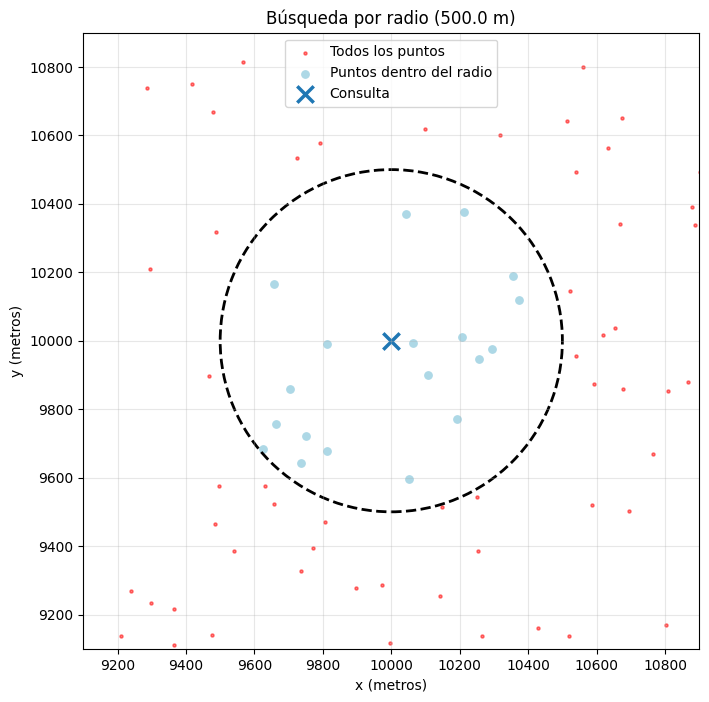

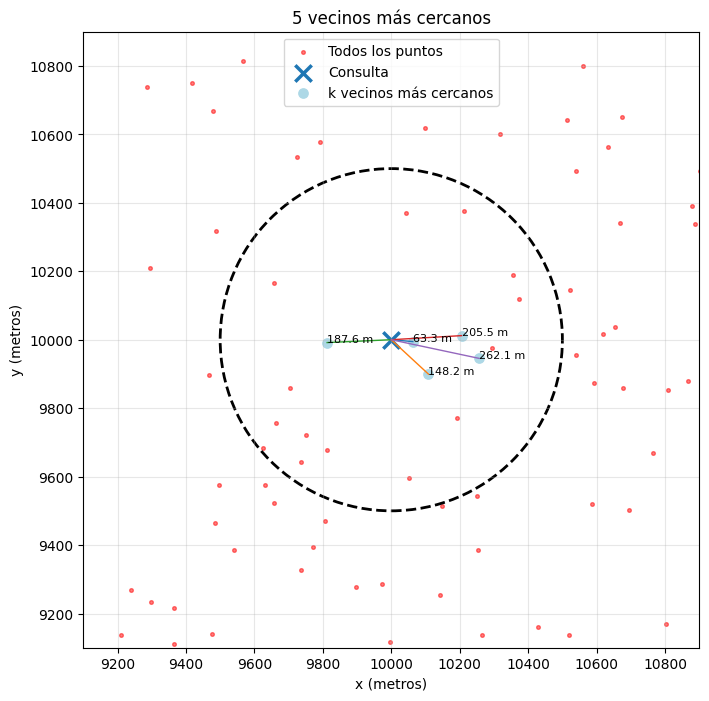

In [89]:
# Programa principal
def main():
    N = 10_000
    K = 2
    RADIUS = 500.0
    K_NEIGHBORS = 5

    # 1) Datos estáticos
    points = generate_static_points(n=N, k=K, seed=42, lower=0.0, upper=20_000.0)

    # 2) Construcción del árbol
    t0 = time.perf_counter()
    tree = KDTree(points)
    t1 = time.perf_counter()
    print(f"KD-Tree construido en {(t1 - t0):.6f} s para {N} puntos de dimensión {K}.")

    # 3) Validación
    validate_random_queries(points, tree, num_tests=50, radius=RADIUS, k_neighbors=K_NEIGHBORS)

    # 4) Benchmark
    benchmark(points, tree, num_queries=300, radius=RADIUS, k_neighbors=K_NEIGHBORS)

    # 5) Consulta ejemplo para visualización
    query = (10_000.0, 10_000.0)

    found_kd = tree.range_search(query, RADIUS)
    nearest_kd = tree.nearest_neighbor(query)
    knn_kd = tree.k_nearest(query, K_NEIGHBORS)
    knn_in_radius_kd = tree.k_nearest(query, K_NEIGHBORS, max_radius=RADIUS)

    print("\nCONSULTA EJEMPLO")
    print(f"Query: {query}")
    print(f"Puntos dentro de {RADIUS} m: {len(found_kd)}")
    print(f"Vecino más cercano: distancia={nearest_kd[2]:.3f} m, índice={nearest_kd[0]}")


    print(f"\n{k_neighbors_label(K_NEIGHBORS)} más cercanos dentro de {RADIUS} m:")
    for idx, p, d in knn_in_radius_kd:
        print(f" distancia={d:.3f} m, idx={idx:5d}")

    # 6) Visualizaciones
    plot_radius_search(
        points,
        query,
        RADIUS,
        found_kd,
        title=f"Búsqueda por radio ({RADIUS} m)"
    )

    plot_k_nearest(
        points,
        query,
        knn_kd,
        radius=RADIUS,
        title=f"{K_NEIGHBORS} vecinos más cercanos"
    )

def k_neighbors_label(k: int) -> str:
    return f"{k} vecino" if k == 1 else f"{k} vecinos"


if __name__ == "__main__":
    main()

**METRICAS DE RENDIMIENTO**


TABLA DE RESULTADOS (PROMEDIOS)

Método         Fuerza Bruta        KD-Tree             
-------------------------------------------------------
Range          0.011899            0.000199            
Nearest        0.011994            0.000068            
k-NN           0.021063            0.000159            


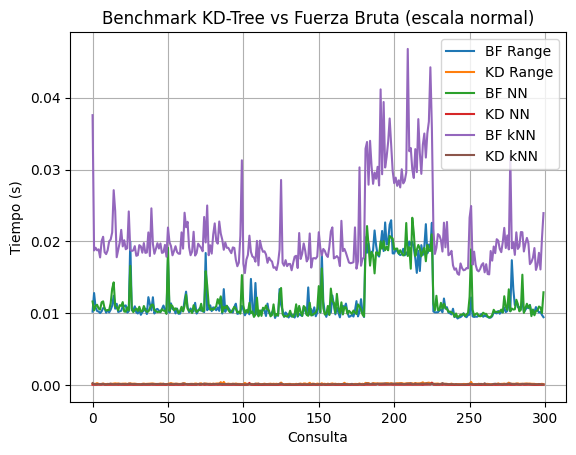

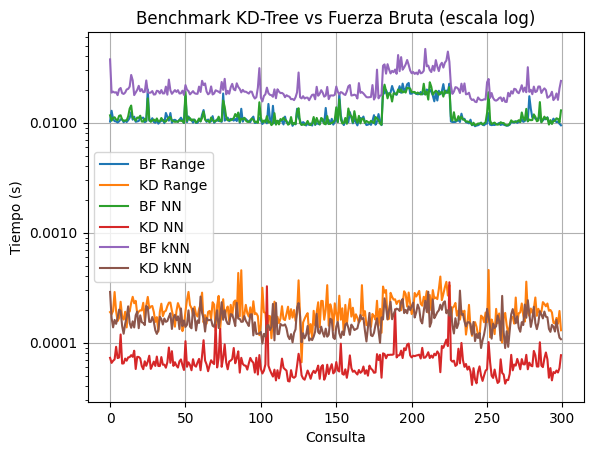

In [90]:
import time
import random
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# =========================
# PARÁMETROS
# =========================
N = 10000
RADIUS = 500.0
K_NEIGHBORS = 5
NUM_QUERIES = 300
SEED = 42

# =========================
# DATOS
# =========================
points = generate_static_points(n=N, k=2, seed=SEED)
tree = KDTree(points)

rng = random.Random(SEED)

queries = [
    tuple(rng.uniform(0.0, 20000.0) for _ in range(2))
    for _ in range(NUM_QUERIES)
]

# =========================
# MEDICIÓN
# =========================
bf_range, kd_range = [], []
bf_nn, kd_nn = [], []
bf_knn, kd_knn = [], []

for q in queries:

    # RANGE
    t0 = time.perf_counter()
    brute_force_range_search(points, q, RADIUS)
    t1 = time.perf_counter()
    bf_range.append(t1 - t0)

    t2 = time.perf_counter()
    tree.range_search(q, RADIUS)
    t3 = time.perf_counter()
    kd_range.append(t3 - t2)

    # NN
    t4 = time.perf_counter()
    brute_force_nearest_neighbor(points, q)
    t5 = time.perf_counter()
    bf_nn.append(t5 - t4)

    t6 = time.perf_counter()
    tree.nearest_neighbor(q)
    t7 = time.perf_counter()
    kd_nn.append(t7 - t6)

    # KNN
    t8 = time.perf_counter()
    brute_force_k_nearest(points, q, K_NEIGHBORS)
    t9 = time.perf_counter()
    bf_knn.append(t9 - t8)

    t10 = time.perf_counter()
    tree.k_nearest(q, K_NEIGHBORS)
    t11 = time.perf_counter()
    kd_knn.append(t11 - t10)

# =========================
# PROMEDIOS
# =========================
avg_bf_range = sum(bf_range)/len(bf_range)
avg_kd_range = sum(kd_range)/len(kd_range)

avg_bf_nn = sum(bf_nn)/len(bf_nn)
avg_kd_nn = sum(kd_nn)/len(kd_nn)

avg_bf_knn = sum(bf_knn)/len(bf_knn)
avg_kd_knn = sum(kd_knn)/len(kd_knn)

# =========================
# TABLA
# =========================
print("\nTABLA DE RESULTADOS (PROMEDIOS)\n")

print(f"{'Método':<15}{'Fuerza Bruta':<20}{'KD-Tree':<20}")
print("-"*55)

print(f"{'Range':<15}{avg_bf_range:<20.6f}{avg_kd_range:<20.6f}")
print(f"{'Nearest':<15}{avg_bf_nn:<20.6f}{avg_kd_nn:<20.6f}")
print(f"{'k-NN':<15}{avg_bf_knn:<20.6f}{avg_kd_knn:<20.6f}")

# =========================
# GRÁFICA NORMAL
# =========================
plt.figure()

plt.plot(bf_range, label="BF Range")
plt.plot(kd_range, label="KD Range")

plt.plot(bf_nn, label="BF NN")
plt.plot(kd_nn, label="KD NN")

plt.plot(bf_knn, label="BF kNN")
plt.plot(kd_knn, label="KD kNN")

plt.xlabel("Consulta")
plt.ylabel("Tiempo (s)")
plt.title("Benchmark KD-Tree vs Fuerza Bruta (escala normal)")
plt.legend()
plt.grid(True)

plt.show()

# =========================
# GRÁFICA LOG
# =========================
plt.figure()

plt.plot(bf_range, label="BF Range")
plt.plot(kd_range, label="KD Range")

plt.plot(bf_nn, label="BF NN")
plt.plot(kd_nn, label="KD NN")

plt.plot(bf_knn, label="BF kNN")
plt.plot(kd_knn, label="KD kNN")

# Escala log
plt.yscale('log')

# Quitar notación científica
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().ticklabel_format(style='plain', axis='y')

plt.xlabel("Consulta")
plt.ylabel("Tiempo (s)")
plt.title("Benchmark KD-Tree vs Fuerza Bruta (escala log)")
plt.legend()
plt.grid(True)

plt.show()

El análisis del benchmark muestra una diferencia significativa entre los algoritmos evaluados. En todas las operaciones (range search, nearest neighbor y k-nearest neighbors), la fuerza bruta presenta tiempos de ejecución considerablemente mayores, debido a su complejidad lineal al recorrer todos los puntos. En contraste, el KD-Tree mantiene tiempos de ejecución mucho más bajos y estables gracias a su estructura jerárquica y la poda de ramas durante la búsqueda. Esta diferencia es especialmente notable en consultas repetidas, donde el KD-Tree demuestra ser altamente eficiente. Los resultados confirman que, para conjuntos de datos grandes como el utilizado (10.000 puntos), el KD-Tree supera ampliamente a la fuerza bruta en rendimiento, siendo una solución más adecuada para aplicaciones de búsqueda espacial.

**¿Para qué tamaño de datos el arbol-KD comienza a ser mas rapido que "fuerza bruta"
(no arboles, si listas, ...)?**

R// El KD-Tree empieza a ser más rápido aproximadamente desde unos 2.000–5.000 puntos, y es claramente mejor en datasets grandes (≥10.000), especialmente cuando hay muchas consultas.

**PRUEBAS UNITARIAS**

In [91]:
import unittest
import random

# =========================
# TEST DISTANCIAS
# =========================

class TestDistances(unittest.TestCase):

    def test_squared_distance(self):
        self.assertAlmostEqual(
            squared_distance((0.0, 0.0), (3.0, 4.0)), 25.0, places=9
        )

    def test_euclidean_distance(self):
        self.assertAlmostEqual(
            euclidean_distance((0.0, 0.0), (1.0, 2.0)),
            5.0 ** 0.5, places=9
        )


class TestDistanceProperties(unittest.TestCase):

    def test_simetria(self):
        a = (1.0, 2.0)
        b = (5.0, 6.0)

        self.assertAlmostEqual(
            euclidean_distance(a, b),
            euclidean_distance(b, a),
            places=9
        )

    def test_distancia_cero(self):
        a = (3.3, 4.4)
        self.assertEqual(euclidean_distance(a, a), 0.0)

    def test_monotonia(self):
        a = (0.0, 0.0)
        b = (1.0, 1.0)
        c = (5.0, 5.0)

        self.assertLess(
            euclidean_distance(a, b),
            euclidean_distance(a, c)
        )


# =========================
# TEST KD-TREE
# =========================

class TestKDTree(unittest.TestCase):

    def setUp(self):
        self.points = [(1.0,2.0),(3.0,4.0),(5.0,6.0),(7.0,8.0),(9.0,10.0)]
        self.tree   = KDTree(self.points)
        self.query  = (4.0, 5.0)

    def test_build_raises_empty(self):
        with self.assertRaises(ValueError):
            KDTree([])

    def test_build_raises_dim(self):
        with self.assertRaises(ValueError):
            KDTree([(1.0, 2.0), (1.0, 2.0, 3.0)])

    def test_range_search_basic(self):
        res = self.tree.range_search((3.0, 4.0), 0.0)
        self.assertEqual(len(res), 1)
        self.assertEqual(res[0][0], 1)

    def test_range_search_vs_brute(self):
        kd = [x[0] for x in self.tree.range_search(self.query, 3.0)]
        bf = [x[0] for x in brute_force_range_search(
            self.points, self.query, 3.0)]

        self.assertEqual(set(kd), set(bf))

    def test_range_search_empty(self):
        res = self.tree.range_search((99.0, 99.0), 0.0)
        self.assertEqual(res, [])

    def test_range_search_dim_error(self):
        with self.assertRaises(ValueError):
            self.tree.range_search((1.0,), 10.0)

    def test_nearest_neighbor(self):
        kd = self.tree.nearest_neighbor(self.query)
        bf = brute_force_nearest_neighbor(self.points, self.query)
        self.assertAlmostEqual(kd[2], bf[2], places=6)

    def test_nearest_neighbor_exact(self):
        idx, pt, dist = self.tree.nearest_neighbor((5.0, 6.0))
        self.assertAlmostEqual(dist, 0.0, places=9)

    def test_k_nearest_basic(self):
        k = 3
        res = self.tree.k_nearest(self.query, k)
        self.assertEqual(len(res), k)

        dists = [r[2] for r in res]
        self.assertEqual(dists, sorted(dists))

    def test_k_nearest_vs_brute(self):
        kd = [round(x[2], 10) for x in self.tree.k_nearest(self.query, 3)]
        bf = [round(x[2], 10) for x in
              brute_force_k_nearest(self.points, self.query, 3)]
        self.assertEqual(kd, bf)

    def test_k_nearest_with_radius(self):
        res = self.tree.k_nearest(self.query, 5, max_radius=2.0)
        for _, _, d in res:
            self.assertLessEqual(d, 2.0 + 1e-9)



print("\nEjecutando pruebas\n")

suite = unittest.TestLoader().loadTestsFromModule(__import__(__name__))
runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)

print("\n RESUMEN FINAL:")
print("Tests ejecutados:", result.testsRun)
print("Errores:", len(result.errors))
print("Fallos:", len(result.failures))

test_nn_vs_knn (__main__.TestConsistency.test_nn_vs_knn) ... ok
test_distancia_cero (__main__.TestDistanceProperties.test_distancia_cero) ... ok
test_monotonia (__main__.TestDistanceProperties.test_monotonia) ... ok
test_simetria (__main__.TestDistanceProperties.test_simetria) ... ok
test_euclidean_distance (__main__.TestDistances.test_euclidean_distance) ... ok
test_squared_distance (__main__.TestDistances.test_squared_distance) ... ok
test_puntos_duplicados (__main__.TestEdgeCases.test_puntos_duplicados) ... ok
test_radio_grande (__main__.TestEdgeCases.test_radio_grande) ... ok
test_build_raises_dim (__main__.TestKDTree.test_build_raises_dim) ... ok
test_build_raises_empty (__main__.TestKDTree.test_build_raises_empty) ... ok
test_k_nearest_basic (__main__.TestKDTree.test_k_nearest_basic) ... ok
test_k_nearest_vs_brute (__main__.TestKDTree.test_k_nearest_vs_brute) ... ok
test_k_nearest_with_radius (__main__.TestKDTree.test_k_nearest_with_radius) ... ok
test_nearest_neighbor (__main__.


Ejecutando pruebas

[OK] Validación superada con 20 consultas aleatorias.

 RESUMEN FINAL:
Tests ejecutados: 24
Errores: 0
Fallos: 0


**ANALISIS DE RENDIMIENTO**

El análisis de rendimiento evidencia una diferencia significativa entre el enfoque de fuerza bruta y el KD-Tree. Mientras que la fuerza bruta presenta un comportamiento lineal evaluando todos los puntos en cada consulta, el KD-Tree optimiza las búsquedas mediante particiones espaciales, reduciendo considerablemente el número de comparaciones. En las pruebas realizadas, el KD-Tree fue hasta más de 100 veces más rápido en promedio, lo que lo hace altamente eficiente para aplicaciones con grandes volúmenes de datos y múltiples consultas, como sistemas de logística o geolocalización. Además, las pruebas unitarias confirmaron la correctitud y robustez de la implementación, validando tanto casos normales como extremos.